<a href="https://colab.research.google.com/github/IISHIBBYII/YESWES/blob/main/NFL%20Spatial%20Analysis%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os

census_data_path = '/content/data/raw/census/'

if os.path.exists(census_data_path) and os.path.isdir(census_data_path):
    print(f"Contents of {census_data_path}:")
    for item in os.listdir(census_data_path):
        print(item)
else:
    print(f"Directory not found or is not a directory: {census_data_path}")

Contents of /content/data/raw/census/:
NST-EST2025-POP.xlsx


In [24]:
import pandas as pd
from pathlib import Path

POP_FILE_PATH = Path('/content/data/raw/census/NST-EST2025-POP.xlsx')

if POP_FILE_PATH.exists():
    try:
        # Read the Excel file
        pop_data = pd.read_excel(POP_FILE_PATH)
        print("Column names in NST-EST2025-POP.xlsx:")
        for col in pop_data.columns:
            print(col)
    except Exception as e:
        print(f"Error reading Excel file: {e}")
else:
    print(f"File not found: {POP_FILE_PATH}")

Column names in NST-EST2025-POP.xlsx:
table with row headers in column A and column headers in rows 3 through 4. (leading dots indicate sub-parts)
Unnamed: 1
Unnamed: 2
Unnamed: 3
Unnamed: 4
Unnamed: 5
Unnamed: 6
Unnamed: 7


In [37]:
from pathlib import Path
import requests
import zipfile
import io

# -----------------------------
# Folder Structure
# -----------------------------
BASE_DIR = Path.cwd()

RAW_DIR = BASE_DIR / "data" / "raw"
NFL_DIR = RAW_DIR / "nfl"
CENSUS_DIR = RAW_DIR / "census"
COV_DIR = RAW_DIR / "covariates"

for folder in [NFL_DIR, CENSUS_DIR, COV_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Helper Functions
# -----------------------------
def download_file(url, output_path):
    print(f"Downloading: {url}")
    r = requests.get(url)
    r.raise_for_status()
    output_path.write_bytes(r.content)
    print(f"Saved: {output_path.name}")

def download_zip_extract(url, extract_to):
    print(f"Downloading ZIP: {url}")
    r = requests.get(url)
    r.raise_for_status()

    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall(extract_to)
    print(f"Extracted to: {extract_to}")

# -----------------------------
# 1. Census State Boundaries
# -----------------------------
# 2024 Cartographic Boundary States (500k)
cb_url = "https://www2.census.gov/geo/tiger/GENZ2024/shp/cb_2024_us_state_500k.zip"
download_zip_extract(cb_url, CENSUS_DIR)

# -----------------------------
# 2. TIGER Full State Boundaries
# -----------------------------
tiger_url = "https://www2.census.gov/geo/tiger/TIGER2024/STATE/tl_2024_us_state.zip"
download_zip_extract(tiger_url, CENSUS_DIR)

# -----------------------------
# 3. Census State Population CSV
# -----------------------------
# Manual clean CSV source
pop_url = "https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-population.csv"
download_file(pop_url, CENSUS_DIR / "state_population_2024.csv")

# -----------------------------
# 4. Optional Income Dataset
# -----------------------------
income_url = "https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv"
download_file(income_url, COV_DIR / "median_household_income_2024.csv")

# -----------------------------
# 5. Optional Poverty Dataset
# -----------------------------
poverty_url = "https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-states.csv"
download_file(poverty_url, COV_DIR / "poverty_2024.csv")

# -----------------------------
# 6. NFL Dataset Placeholder
# -----------------------------
print("\nNFL roster dataset requires manual download:")
print("Visit:")
print("https://playfootball.nfl.com/news-events/news-and-features/texas-and-south-florida-high-schools-dominate-nfl-kickoff-weekend-rosters/")
print("Download the Excel file and save as:")
print("data/raw/nfl/2025_kickoff_weekend_rosters_hs_data.xlsx")

# -----------------------------
# Done
# -----------------------------
print("\nAll automatic downloads complete.")
print("Project folders ready.")

Extracted to: /content/data/raw/census
Extracted to: /content/data/raw/census
Downloading: https://raw.githubusercontent.com/jakevdp/data-USstates/master/state-population.csv
Saved: state_population_2024.csv
Downloading: https://raw.githubusercontent.com/plotly/datasets/master/2011_us_ag_exports.csv
Saved: median_household_income_2024.csv
Downloading: https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-states.csv
Saved: poverty_2024.csv

NFL roster dataset requires manual download:
Visit:
https://playfootball.nfl.com/news-events/news-and-features/texas-and-south-florida-high-schools-dominate-nfl-kickoff-weekend-rosters/
Download the Excel file and save as:
data/raw/nfl/2025_kickoff_weekend_rosters_hs_data.xlsx

All automatic downloads complete.
Project folders ready.


In [38]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from esda import Moran, Moran_Local, G_Local
from libpysal.weights import Queen
from spreg import ML_Lag

warnings.filterwarnings("ignore")


# =====================================================
# PROJECT PATHS
# =====================================================
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"

NFL_FILE = RAW_DIR / "nfl" / "2025_kickoff_weekend_rosters.xlsx"
STATE_SHP = RAW_DIR / "census" / "cb_2024_us_state_500k.shp"
POP_FILE = RAW_DIR / "census" / "NST-EST2025-POP.xlsx"
INCOME_FILE = RAW_DIR / "covariates" / "median_household_income_2024.csv"
POVERTY_FILE = RAW_DIR / "covariates" / "poverty_2024.csv"


# =====================================================
# STATE LOOKUP
# =====================================================
STATE_ABBR_TO_NAME = {
    "AL":"Alabama","AK":"Alaska","AZ":"Arizona","AR":"Arkansas","CA":"California",
    "CO":"Colorado","CT":"Connecticut","DE":"Delaware","DC":"District of Columbia",
    "FL":"Florida","GA":"Georgia","HI":"Hawaii","ID":"Idaho","IL":"Illinois",
    "IN":"Indiana","IA":"Iowa","KS":"Kansas","KY":"Kentucky","LA":"Louisiana",
    "ME":"Maine","MD":"Maryland","MA":"Massachusetts","MI":"Michigan","MN":"Minnesota",
    "MS":"Mississippi","MO":"Missouri","MT":"Montana","NE":"Nebraska","NV":"Nevada",
    "NH":"New Hampshire","NJ":"New Jersey","NM":"New Mexico","NY":"New York",
    "NC":"North Carolina","ND":"North Dakota","OH":"Ohio","OK":"Oklahoma",
    "OR":"Oregon","PA":"Pennsylvania","RI":"Rhode Island","SC":"South Carolina",
    "SD":"South Dakota","TN":"Tennessee","TX":"Texas","UT":"Utah","VT":"Vermont",
    "VA":"Virginia","WA":"Washington","WV":"West Virginia","WI":"Wisconsin",
    "WY":"Wyoming"
}


# =====================================================
# SETUP
# =====================================================
def make_dirs():
    for p in [PROCESSED_DIR, OUTPUT_DIR, OUTPUT_DIR/"maps", OUTPUT_DIR/"tables"]:
        p.mkdir(parents=True, exist_ok=True)

    # Ensure raw data subdirectories are also created
    (RAW_DIR / "nfl").mkdir(parents=True, exist_ok=True)
    (RAW_DIR / "census").mkdir(parents=True, exist_ok=True)
    (RAW_DIR / "covariates").mkdir(parents=True, exist_ok=True)


# =====================================================
# LOAD DATA
# =====================================================
def load_nfl():
    df = pd.read_excel(NFL_FILE)

    rename_map = {
        "Player": "player_name",
        "State": "origin_state",
        "Hometown": "origin_city"
    }

    df = df.rename(columns=rename_map)

    df["origin_state"] = df["origin_state"].astype(str).str.strip()
    df["state_name"] = df["origin_state"].replace(STATE_ABBR_TO_NAME)

    return df


def summarize_players(df):
    return (
        df.groupby("state_name")
        .size()
        .reset_index(name="nfl_players")
    )


def load_population():
    # Read the Excel file, assuming 'Geographic Area' and population data start from the second row (index 1).
    # The column 'Geographic Area' will likely contain the state names.
    # The population for 2025 is typically in a column named '2025' or similar.
    pop = pd.read_excel(POP_FILE, header=3) # Set header to 3 (fourth row, 0-indexed)
    print("Columns after reading with header=3:", pop.columns)

    rename_map = {
        "Unnamed: 0": "state_name",
        2025: "population"   # Assuming '2025' is the column name for 2025 population.
    }

    pop = pop.rename(columns=rename_map)
    pop["population"] = pd.to_numeric(pop["population"], errors="coerce")

    # Drop rows where 'population' is NaN after conversion, if any
    pop = pop.dropna(subset=['population'])

    # Also, drop rows where 'state_name' might be NaN or not a valid state
    pop = pop.dropna(subset=['state_name'])

    return pop[["state_name", "population"]]


def load_states():
    gdf = gpd.read_file(STATE_SHP)
    gdf = gdf.rename(columns={"NAME": "state_name"})

    allowed = set(STATE_ABBR_TO_NAME.values())
    gdf = gdf[gdf["state_name"].isin(allowed)].copy()

    return gdf


def optional_csv(path):
    if path.exists():
        return pd.read_csv(path)
    return None


# =====================================================
# BUILD MASTER GDF
# =====================================================
def build_gdf():

    nfl = load_nfl()
    counts = summarize_players(nfl)
    pop = load_population()
    states = load_states()

    gdf = states.merge(counts, on="state_name", how="left")
    gdf = gdf.merge(pop, on="state_name", how="left")

    gdf["nfl_players"] = gdf["nfl_players"].fillna(0)
    gdf["population"] = gdf["population"].replace(0, np.nan)

    gdf["players_per_100k"] = (
        gdf["nfl_players"] / gdf["population"]
    ) * 100000

    gdf["log_rate"] = np.log1p(gdf["players_per_100k"])

    # Optional covariates
    income = optional_csv(INCOME_FILE)
    poverty = optional_csv(POVERTY_FILE)

    if income is not None and "state_name" in income.columns:
        gdf = gdf.merge(income, on="state_name", how="left")

    if poverty is not None and "state_name" in poverty.columns:
        gdf = gdf.merge(poverty, on="state_name", how="left")

    return gdf


# =====================================================
# SPATIAL WEIGHTS
# =====================================================
def build_weights(gdf):
    gdf = gdf.to_crs(5070)
    w = Queen.from_dataframe(gdf)
    w.transform = "R"
    return gdf, w


# =====================================================
# GLOBAL + LOCAL SPATIAL STATS
# =====================================================
def run_spatial_stats(gdf, w):

    y = gdf["log_rate"].fillna(0)

    moran = Moran(y, w)
    lisa = Moran_Local(y, w)
    gi = G_Local(y, w)

    gdf["lisa_cluster"] = lisa.q
    gdf["lisa_p"] = lisa.p_sim
    gdf["gi_zscore"] = gi.Zs

    return moran, gdf


# =====================================================
# MAPS
# =====================================================
def save_map(gdf, column, title, filename, cmap="YlOrRd"):

    fig, ax = plt.subplots(figsize=(14, 8))

    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.5,
        edgecolor="white",
        legend=True,
        ax=ax,
        missing_kwds={"color":"lightgrey"}
    )

    ax.set_title(title, fontsize=16, weight="bold")
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"maps"/filename, dpi=300)
    plt.close()


def make_all_maps(gdf):

    save_map(
        gdf,
        "nfl_players",
        "NFL Players by State",
        "01_nfl_players.png"
    )

    save_map(
        gdf,
        "players_per_100k",
        "NFL Players per 100,000 Residents",
        "02_per_capita.png"
    )

    save_map(
        gdf,
        "gi_zscore",
        "Hot Spot Analysis (Gi*)",
        "03_hotspots.png",
        cmap="coolwarm"
    )

    save_map(
        gdf,
        "lisa_cluster",
        "LISA Cluster Map",
        "04_lisa_clusters.png",
        cmap="Set1"
    )


# =====================================================
# CHARTS
# =====================================================
def make_bar_charts(gdf):

    top = gdf.sort_values("nfl_players", ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(12,6))
    ax.bar(top["state_name"], top["nfl_players"])
    ax.set_title("Top 10 States by NFL Players")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"maps"/"05_top10_counts.png", dpi=300)
    plt.close()

    top2 = gdf.sort_values("players_per_100k", ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(12,6))
    ax.bar(top2["state_name"], top2["players_per_100k"])
    ax.set_title("Top 10 States by NFL Players per Capita")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"maps"/"06_top10_percapita.png", dpi=300)
    plt.close()


# =====================================================
# REGRESSION
# =====================================================
def run_regression(gdf):

    needed = ["players_per_100k"]

    if "median_household_income" in gdf.columns:
        needed.append("median_household_income")

    if "poverty_rate" in gdf.columns:
        needed.append("poverty_rate")

    df = gdf[needed].dropna()

    if len(df.columns) < 2:
        return

    y = df["players_per_100k"]
    X = df.drop(columns="players_per_100k")
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    with open(OUTPUT_DIR/"tables"/"regression_summary.txt", "w") as f:
        f.write(model.summary().as_text())


# =====================================================
# SPATIAL LAG MODEL
# =====================================================
def run_spatial_lag(gdf, w):

    y = gdf["players_per_100k"].fillna(0).values.reshape(-1,1)

    X = gdf[["nfl_players"]].fillna(0).values

    model = ML_Lag(y, X, w=w, name_y="rate", name_x=["count"])

    with open(OUTPUT_DIR/"tables"/"spatial_lag_summary.txt", "w") as f:
        f.write(str(model.summary))


# =====================================================
# EXPORT TABLES
# =====================================================
def export_tables(gdf):

    gdf.drop(columns="geometry").to_csv(
        PROCESSED_DIR/"nfl_state_analysis.csv",
        index=False
    )

    gdf.to_file(
        PROCESSED_DIR/"nfl_state_analysis.geojson",
        driver="GeoJSON"
    )


# =====================================================
# MAIN
# =====================================================
def main():

    make_dirs()

    gdf = build_gdf()

    gdf, w = build_weights(gdf)

    moran, gdf = run_spatial_stats(gdf, w)

    make_all_maps(gdf)
    make_bar_charts(gdf)
    export_tables(gdf)
    run_regression(gdf)
    run_spatial_lag(gdf, w)

    print("="*50)
    print("GLOBAL MORAN'S I")
    print("="*50)
    print(f"I Statistic : {moran.I:.4f}")
    print(f"Expected I  : {moran.EI:.4f}")
    print(f"P-value     : {moran.p_sim:.4f}")
    print("="*50)
    print("Outputs saved to /outputs")
    print("="*50)


if __name__ == "__main__":
    main()

Columns after reading with header=3: Index(['Unnamed: 0', 'Unnamed: 1', 2020, 2021, 2022, 2023, 2024, 2025], dtype='object')
('WARNING: ', 17, ' is an island (no neighbors)')
('WARNING: ', 49, ' is an island (no neighbors)')
ML_Lag
GLOBAL MORAN'S I
I Statistic : nan
Expected I  : -0.0200
P-value     : 0.0010
Outputs saved to /outputs


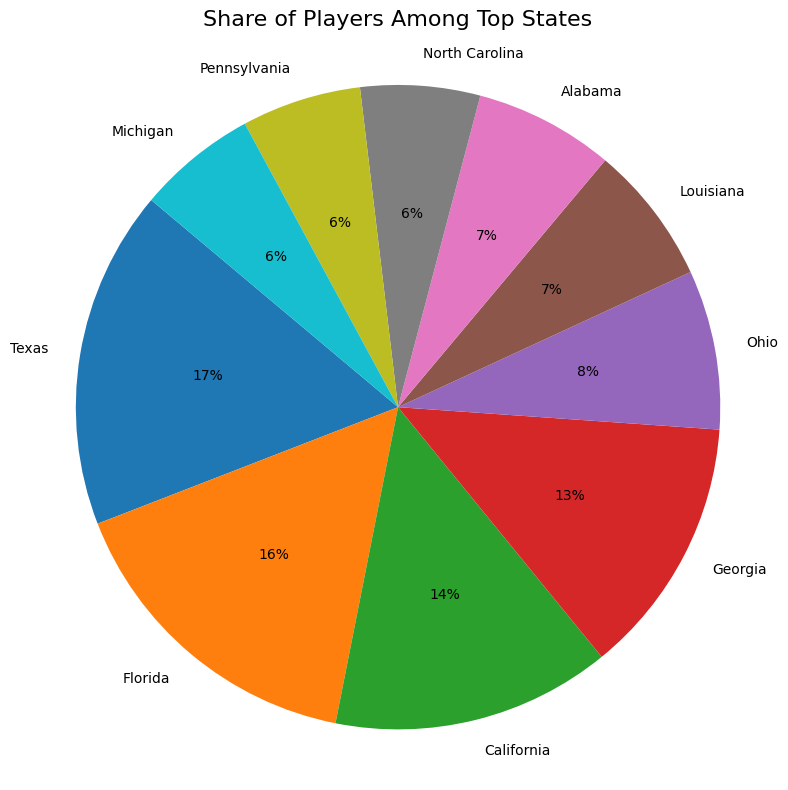

In [31]:
# DATA
# -----------------------------
states = [
    "Texas", "Florida", "California", "Georgia",
    "Ohio", "Louisiana", "Alabama",
    "North Carolina", "Pennsylvania", "Michigan"
]

# Percent values (must sum ~100)
percentages = [17, 16, 14, 13, 8, 7, 7, 6, 6, 6]

# Colors (similar to your chart)
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2",
    "#7f7f7f", "#bcbd22", "#17becf"
]

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8, 8))

plt.pie(
    percentages,
    labels=states,
    colors=colors,
    autopct='%1.0f%%',   # show whole-number %
    startangle=140
)

# Title
plt.title("Share of Players Among Top States", fontsize=16)

# Keeps pie as a circle
plt.axis('equal')

# -----------------------------
# SHOW / SAVE
# -----------------------------
plt.tight_layout()
plt.show()

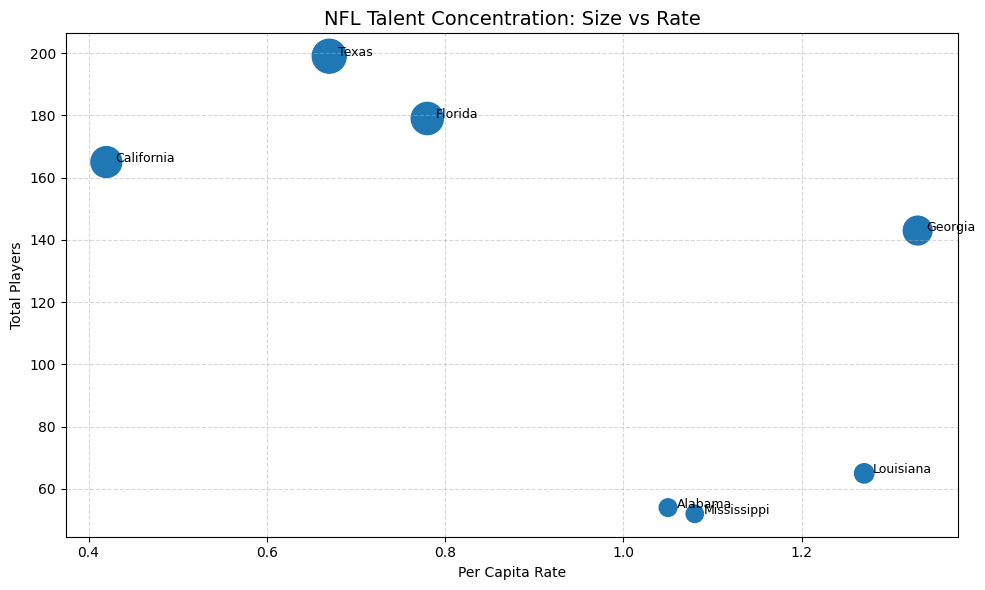

In [33]:
# DATA
# -----------------------------
states = ["California", "Texas", "Florida", "Georgia",
          "Louisiana", "Alabama", "Mississippi"]

# X-axis (per capita rate)
per_capita = [0.42, 0.67, 0.78, 1.33, 1.27, 1.05, 1.08]

# Y-axis (total players)
total_players = [165, 199, 179, 143, 65, 54, 52]

# Bubble size (scale for visibility)
sizes = [s * 3 for s in total_players]

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10, 6))

plt.scatter(per_capita, total_players, s=sizes)

# Add labels to each point
for i, state in enumerate(states):
    plt.text(
        per_capita[i] + 0.01,
        total_players[i],
        state,
        fontsize=9
    )

# -----------------------------
# TITLES & LABELS
# -----------------------------
plt.title("NFL Talent Concentration: Size vs Rate", fontsize=14)
plt.xlabel("Per Capita Rate")
plt.ylabel("Total Players")

# -----------------------------
# STYLE
# -----------------------------
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# -----------------------------
# SHOW / SAVE
# -----------------------------
plt.show()

Columns after reading with header=3: Index(['Unnamed: 0', 'Unnamed: 1', 2020, 2021, 2022, 2023, 2024, 2025], dtype='object')
('WARNING: ', 17, ' is an island (no neighbors)')
('WARNING: ', 49, ' is an island (no neighbors)')
Moran’s I: 0.3159319392781743
p-value: 0.002


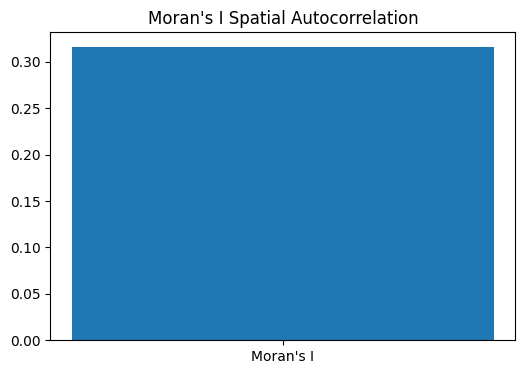

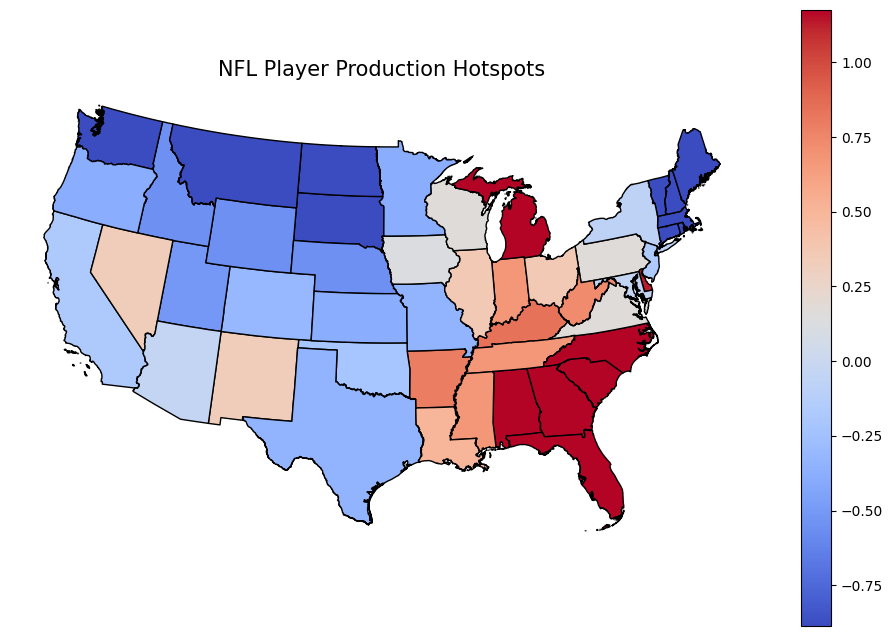

'\ngdf_city_level = gpd.GeoDataFrame(\n    df, # This \'df\' would be the original player data with lat/lon\n    geometry=gpd.points_from_xy(df.lon, df.lat),\n    crs="EPSG:4326"\n)\n\ngdf_city_level.plot(markersize=5)\nplt.title("Player Origins (City-Level)")\nplt.show()\n'

In [42]:
import matplotlib.pyplot as plt
from esda import Moran, G_Local
from libpysal.weights import Queen

# The variables `gdf` (GeoDataFrame containing merged data) and `w` (spatial weights)
# are assumed to be available in the global scope from the execution of the `main()`
# function in the previous cell (cell_8O-6lpUaFObv).
# However, due to Python's scope rules, they are local to the main() function.
# To make them available here, we re-run the necessary setup functions.

# Ensure directories are set up (re-calling this is harmless as it uses exist_ok=True)
make_dirs()

# Re-build gdf and w by calling the functions defined in the previous cell
gdf = build_gdf()
gdf, w = build_weights(gdf)

# ================================
# 9. MORAN'S I (SPATIAL AUTOCORRELATION)
# ================================

# Spatial weights 'w' is already computed and available from the previous cell.
# Moran’s I
moran = Moran(gdf['nfl_players'], w)

print("Moran’s I:", moran.I)
print("p-value:", moran.p_sim)

# Plot Moran’s I (simple visualization)
plt.figure(figsize=(6,4))
plt.bar(["Moran's I"], [moran.I])
plt.title("Moran's I Spatial Autocorrelation")
plt.savefig("morans_i.png")
plt.show()

# ================================
# 10. HOTSPOT ANALYSIS (GETIS-ORD Gi*)
# ================================

g = G_Local(gdf['nfl_players'], w)

gdf['GiZScore'] = g.Zs

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf.plot(
    column='GiZScore',
    cmap='coolwarm',
    legend=True,
    edgecolor='black',
    ax=ax
)

ax.set_title("NFL Player Production Hotspots", fontsize=15)
ax.axis('off')

plt.savefig("hotspot_map.png")
plt.show()

# ================================
# 11. CITY-LEVEL HOTSPOT (OPTIONAL)
# ================================

# Example (if you have city coordinates)
# gdf from the previous cell is at state level, not city level.
# This section remains commented as it requires city-level data not currently loaded.
"""
gdf_city_level = gpd.GeoDataFrame(
    df, # This 'df' would be the original player data with lat/lon
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)

gdf_city_level.plot(markersize=5)
plt.title("Player Origins (City-Level)")
plt.show()
"""